# Budget-Constrained Sequential Information-Seeking Eval — 데모

**연구 질문**: VLM(Vision-Language Model)에게 작은 정보 budget이 주어졌을 때, *지금 답할지 / 텍스트를 더 요청할지 / 시각 정보를 더 요청할지* 매 스텝 잘 판단할 수 있는가?

- **모델**: Qwen2.5-VL-7B-Instruct
- **데이터셋**: ScienceQA (test split, 4-choice MC) — `image` + `hint`/`lecture`가 모두 있는 500개 샘플
- **평가**: 매 스텝 모델이 한 줄 JSON action을 출력하면서 정보를 누적하다가, 정해진 시점에 답을 commit. 최종 답이 정답이면 `is_correct=True`.

이 노트북은 **이미 완료된 결과 파일**을 차례로 로드해서 데모처럼 보여줍니다. 모델 추론을 다시 돌리고 싶으면 노트북 마지막의 *재현 방법* 또는 *라이브 1샘플 데모* 셀 참고.


## 용어 정리

| 용어 | 설명 |
|---|---|
| **VLM (Vision-Language Model)** | 이미지+텍스트를 동시에 입력받아 텍스트로 답하는 모델 (예: Qwen2.5-VL, LLaVA, GPT-4V). |
| **ScienceQA** | 초·중등 과학/언어/사회 교과 멀티모달 MC 데이터셋. 각 샘플은 `question`, `choices`, `answer`, 선택적 `hint`/`lecture`, 선택적 `image`를 포함. |
| **MC (multiple choice)** | 보기 중 정답 1개를 letter(A/B/C/D)로 고르는 형식. |
| **Budget** | 한 샘플에서 쓸 수 있는 정보 요청 횟수의 총합. `ANSWER`은 cost 0, `REQUEST_*`는 cost 1. |
| **Modality** | 정보 출처 종류. 본 실험은 `text`(문장 단위 hint)와 `visual`(이미지 타일) 두 가지. |
| **Text hint** | `hint + lecture`를 정규식으로 문장 분할해 만든 sentence list. `REQUEST_TEXT` 1회당 1문장 공개. |
| **Visual hint (tile)** | 원본 이미지를 N×N(default 2×2 = 4타일) 그리드로 잘라낸 patch. `REQUEST_VISUAL` 1회당 1타일을 *별도 이미지*로 입력. |
| **Action** | 모델이 매 스텝 출력하는 JSON. `{"action": "ANSWER", "choice": "A"}` / `{"action": "REQUEST_TEXT"}` / `{"action": "REQUEST_VISUAL"}`. |
| **Force-answer** | budget이 0이거나 wasted 한도 초과 시 시스템이 "지금 답해라" 프롬프트를 보냄. 이 턴의 ANSWER는 `FORCED_ANSWER`로 기록. |
| **Wasted request** | 이미 소진된 modality나 unparseable JSON을 출력해 정보를 못 얻고 budget만 까먹은 경우. |
| **Refused answer** | force-answer 프롬프트에도 모델이 ANSWER를 안 내고 REQUEST_*만 반복할 때 episode 종료. 무한 루프 방지 cap. |
| **Policy** | 액션 결정 주체. `model`(모델이 결정), `always_text`/`always_visual`(자동 단일 모달리티), `full_info`(모든 정보 upfront + 1턴 답변). |
| **Sweep** | 같은 평가 프로토콜을 유지하면서 **하이퍼파라미터 하나(보통 budget)를 여러 값으로 돌리고** 지표 변화를 보는 방법. "accuracy-vs-budget curve"는 이 sweep의 산출물. |


## 0. 환경 셋업


In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image as IPyImage, Markdown, display

WORKSPACE = Path("/mnt/ddn/prod-runs/thyun.park/src/eval_sufficiency")
PREPROC = WORKSPACE / "preproc"
OUT_ROOT = WORKSPACE / "output"
PLOT_DIR = OUT_ROOT / "plots"

print("Workspace:           ", WORKSPACE)
print("Preproc dir 존재 여부:", PREPROC.exists())
print("Output dir 존재 여부: ", OUT_ROOT.exists())
print("Plot dir 존재 여부:   ", PLOT_DIR.exists())


Workspace:            /mnt/ddn/prod-runs/thyun.park/src/eval_sufficiency
Preproc dir 존재 여부: True
Output dir 존재 여부:  True
Plot dir 존재 여부:    True


## 1. 전처리 결과 미리보기

`preprocessing.py`가 `derek-thomas/ScienceQA` test split (4241개)에서 다음 조건으로 필터링:
- `image`가 있어야 함
- `image` 양변 ≥ 64px
- `hint + lecture`가 60자 이상이고 문장 ≥ 2개

선정된 500개 샘플은 `preproc/samples.parquet`에 저장. 각 샘플은 텍스트 문장 리스트와 4개 타일 PNG를 포함.


In [2]:
samples = pd.read_parquet(PREPROC / "samples.parquet")
print(f"전처리 샘플 수: {len(samples)}")
print(f"컬럼: {list(samples.columns)}")

with open(PREPROC / "preproc_meta.json") as f:
    meta = json.load(f)
display(Markdown("**필터링 통계**"))
display(meta)


전처리 샘플 수: 500
컬럼: ['sample_id', 'question', 'choices', 'choice_letters', 'answer_idx', 'answer_letter', 'subject', 'topic', 'category', 'skill', 'grade', 'text_sentences', 'n_sentences', 'full_image_rel_path', 'tile_rel_paths', 'tile_labels', 'tile_grid', 'n_tiles']


**필터링 통계**

{'hf_repo': 'derek-thomas/ScienceQA',
 'split': 'test',
 'tile_grid': 2,
 'max_samples': 500,
 'kept': 500,
 'skipped_no_image': 715,
 'skipped_small': 10,
 'skipped_text': 183}

### 1-a. 한 샘플 예시 (질문 + 보기 + 원본 + 타일 + 텍스트 문장)


In [3]:
SAMPLE_IDX = 0
row = samples.iloc[SAMPLE_IDX]

display(Markdown(f"**Sample ID**: `{row.sample_id}` &nbsp;&nbsp; **Subject**: `{row.subject}`"))
display(Markdown(f"**Question**: {row.question}"))
choices_md = " · ".join(f"**({l})** {c}" for l, c in zip(row.choice_letters, row.choices))
display(Markdown(f"**Choices**: {choices_md}"))
display(Markdown(f"**정답**: `{row.answer_letter}`  /  **n_sentences**: {row.n_sentences}, **n_tiles**: {row.n_tiles}"))


**Sample ID**: `sqa_000001` &nbsp;&nbsp; **Subject**: `natural science`

**Question**: Which of the following could Gordon's test show?

**Choices**: **(A)** if the spacecraft was damaged when using a parachute with a 1 m vent going 200 km per hour · **(B)** how steady a parachute with a 1 m vent was at 200 km per hour · **(C)** whether a parachute with a 1 m vent would swing too much at 400 km per hour

**정답**: `B`  /  **n_sentences**: 30, **n_tiles**: 4

**원본 이미지** (참고용 — 실제 모델은 타일만 봄):

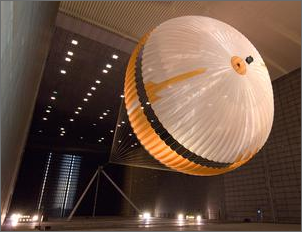

In [4]:
display(Markdown("**원본 이미지** (참고용 — 실제 모델은 타일만 봄):"))
display(IPyImage(filename=str(PREPROC / row.full_image_rel_path), width=320))


**타일 (REQUEST_VISUAL 1회당 1장씩 공개):**

- `top-left`

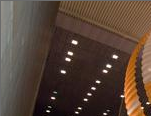

- `top-right`

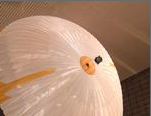

- `bottom-left`

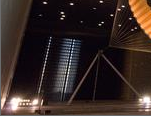

- `bottom-right`

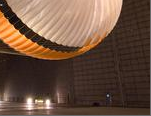

In [5]:
display(Markdown("**타일 (REQUEST_VISUAL 1회당 1장씩 공개):**"))
for label, path in zip(row.tile_labels, row.tile_rel_paths):
    display(Markdown(f"- `{label}`"))
    display(IPyImage(filename=str(PREPROC / path), width=180))


In [6]:
display(Markdown("**텍스트 힌트 (REQUEST_TEXT 1회당 1문장씩 공개):**"))
for k, s in enumerate(list(row.text_sentences), 1):
    print(f"  {k:2d}. {s}")


**텍스트 힌트 (REQUEST_TEXT 1회당 1문장씩 공개):**

   1. People can use the engineering-design process to develop solutions to problems.
   2. One step in the process is testing if a potential solution meets the requirements of the design.
   3. The passage below describes how the engineering-design process was used to test a solution to a problem.
   4. Read the passage.
   5. Then answer the question below.
   6. Gordon was an aerospace engineer who was developing a parachute for a spacecraft that would land on Mars.
   7. He needed to add a vent at the center of the parachute so the spacecraft would land smoothly.
   8. However, the spacecraft would have to travel at a high speed before landing.
   9. If the vent was too big or too small, the parachute might swing wildly at this speed.
  10. The movement could damage the spacecraft.
  11. So, to help decide how big the vent should be, Gordon put a parachute with a 1 m vent in a wind tunnel.
  12. The wind tunnel made it seem like the parachute was moving at 200 km per hour.
  13. He

## 2. 메인 실험 (budget=6, model policy)

`experiment_runner.py`로 500 샘플 모두 실행한 결과를 `output/main_b6/`에서 로드.

매 스텝 모델은 다음 정보를 본다:
- 질문 + 보기
- 지금까지 공개된 텍스트 문장과 이미지 타일들 (모두 같은 user 메시지 안에 인라인)
- 남은 budget, 모달리티별 남은 힌트 수

그리고 한 줄 JSON action을 출력. budget 소진 또는 wasted 한도 초과 시 force-answer 턴이 발생.


In [7]:
def load_run(name):
    return {
        "predictions": pd.read_parquet(OUT_ROOT / name / "predictions.parquet"),
        "summary":     pd.read_csv(OUT_ROOT / name / "summary_overall.csv"),
        "by_subject":  pd.read_csv(OUT_ROOT / name / "summary_by_subject.csv"),
    }

main = load_run("main_b6")
display(Markdown("**Overall summary (main_b6, budget=6, model policy):**"))
display(main["summary"])
display(Markdown("**Subject별:**"))
display(main["by_subject"])


**Overall summary (main_b6, budget=6, model policy):**

,n,accuracy,mean_budget_used,mean_text_requests,mean_visual_requests,mean_wasted,parse_fail_rate,forced_answer_rate,answered_without_info_rate
0,500,0.656,4.178,3.282,0.872,0.024,0.0,0.316,0.028


**Subject별:**

,subject,n,accuracy,mean_budget_used,mean_text_requests,mean_visual_requests
0,language science,14,0.714286,3.500000,2.142857,1.214286
1,natural science,410,0.665854,4.097561,3.229268,0.848780
2,social science,76,0.592105,4.736842,3.776316,0.934211


### 2-a. 1샘플의 step-by-step trace

`predictions.jsonl`은 sample마다 `trace`(스텝별 action 기록)를 포함. 첫 샘플의 trace를 풀어서 보여줌.


In [8]:
with open(OUT_ROOT / "main_b6" / "predictions.jsonl") as f:
    main_trace_rows = [json.loads(l) for l in f]

example = main_trace_rows[0]
display(Markdown(f"**Sample**: `{example['sample_id']}`"))
display(Markdown(f"**Question**: {example['question']}"))
display(Markdown(
    f"**정답**: `{example['answer_letter']}` &nbsp;&nbsp; "
    f"**모델 답**: `{example['final_choice']}` &nbsp;&nbsp; "
    f"**is_correct**: **{example['is_correct']}** &nbsp;&nbsp; "
    f"**final_action**: `{example['final_action']}`"
))

sample_text = dict(zip(samples["sample_id"], samples["text_sentences"]))
print("\nstep-by-step:")
for s in example["trace"]:
    print(f"  step {s['step']}: action={s['action']:<14s} "
          f"budget_before={s['budget_before']} "
          f"text_left={s['text_left_before']} visual_left={s['visual_left_before']}")
    if "revealed_text_idx" in s:
        sent = sample_text[example["sample_id"]][s['revealed_text_idx']]
        print(f"      → revealed text idx {s['revealed_text_idx']}: {sent[:120]}")
    if "revealed_tile_idx" in s:
        print(f"      → revealed tile idx {s['revealed_tile_idx']} (label: {s['revealed_tile_label']})")


**Sample**: `sqa_000001`

**Question**: Which of the following could Gordon's test show?

**정답**: `B` &nbsp;&nbsp; **모델 답**: `B` &nbsp;&nbsp; **is_correct**: **True** &nbsp;&nbsp; **final_action**: `ANSWER`


step-by-step:
  step 1: action=REQUEST_TEXT   budget_before=6 text_left=30 visual_left=4
      → revealed text idx 0: People can use the engineering-design process to develop solutions to problems.
  step 2: action=REQUEST_TEXT   budget_before=5 text_left=29 visual_left=4
      → revealed text idx 1: One step in the process is testing if a potential solution meets the requirements of the design.
  step 3: action=REQUEST_TEXT   budget_before=4 text_left=28 visual_left=4
      → revealed text idx 2: The passage below describes how the engineering-design process was used to test a solution to a problem.
  step 4: action=ANSWER         budget_before=3 text_left=27 visual_left=4


## 3. "Sweep"이 뭔지 — 개념과 실제 예시

**Parameter sweep** = 같은 실험 설정을 유지하면서 **하이퍼파라미터 하나를 여러 값으로 돌리고** 지표가 어떻게 변하는지 보는 방법. 이 프로젝트의 sweep은 `budget` 한 변수만 움직인다.

실제로 돌린 config 리스트 (요약):

```python
# run_sweep.py / run_dense_sweep.py
RUNS = [
    dict(name="zero_info",     policy="model",         budget=0),
    dict(name="sweep_b1",      policy="model",         budget=1),
    dict(name="sweep_b2",      policy="model",         budget=2),
    dict(name="sweep_b3",      policy="model",         budget=3),
    dict(name="sweep_b4",      policy="model",         budget=4),
    dict(name="sweep_b5",      policy="model",         budget=5),
    dict(name="main_b6",       policy="model",         budget=6),
    dict(name="sweep_b7",      policy="model",         budget=7),
    dict(name="sweep_b8",      policy="model",         budget=8),
    dict(name="sweep_b10",     policy="model",         budget=10),
    dict(name="full_info",     policy="full_info",     budget=0),   # 모든 정보 upfront
    dict(name="always_text",   policy="always_text",   budget=6),
    dict(name="always_visual", policy="always_visual", budget=6),
]
```

각 run은 **같은 500 샘플 / 같은 seed / 같은 모델**에 대해 돌아가고, 서로 다른 budget에서 accuracy가 어떻게 달라지는지 기록한다.

### 3-a. 같은 샘플, 다른 budget — trace 비교

아래는 **`sqa_000001` 한 샘플**이 여러 budget에서 각각 어떻게 풀리는지. 같은 질문 · 같은 모델 · 같은 seed인데 **budget 한 변수를 움직이기만 해도** 모델 행동이 달라짐 — 이게 sweep이 드러내는 것.

(note: trace가 저장된 run만 사용. sweep_b4/b8은 용량 절약 차원에서 trace 미저장.)


In [9]:
from textwrap import shorten

TRACE_RUNS = ["sweep_b1", "sweep_b2", "sweep_b3", "sweep_b5", "main_b6", "sweep_b7", "sweep_b10"]

def load_traces(run):
    out = {}
    p = OUT_ROOT / run / "predictions.jsonl"
    if not p.exists():
        return out
    with open(p) as f:
        for line in f:
            r = json.loads(line)
            if r.get("trace"):
                out[r["sample_id"]] = r
    return out

trace_by_run = {run: load_traces(run) for run in TRACE_RUNS}

SAMPLE = "sqa_000001"
first = trace_by_run["main_b6"].get(SAMPLE)
display(Markdown(f"**Sample**: `{first['sample_id']}`"))
display(Markdown(f"**Question**: {first['question']}"))
display(Markdown(f"**정답**: `{first['answer_letter']}`"))

rows = []
for run in TRACE_RUNS:
    r = trace_by_run[run].get(SAMPLE)
    if r is None:
        continue
    actions = [s.get("action", "?") for s in r["trace"]]
    rows.append({
        "run": run,
        "budget": r["budget"],
        "final_action": r["final_action"],
        "final_choice": r["final_choice"],
        "is_correct": r["is_correct"],
        "text_req": r["text_requests"],
        "visual_req": r["visual_requests"],
        "n_steps": r["n_steps"],
        "action_seq": " → ".join(actions),
    })
display(Markdown("**budget별 결과 요약 (`sqa_000001`):**"))
display(pd.DataFrame(rows))


**Sample**: `sqa_000001`

**Question**: Which of the following could Gordon's test show?

**정답**: `B`

**budget별 결과 요약 (`sqa_000001`):**

,run,budget,final_action,final_choice,is_correct,text_req,visual_req,n_steps,action_seq
0,sweep_b1,1,FORCED_ANSWER,B,True,1,0,2,REQUEST_TEXT → ANSWER
1,sweep_b2,2,FORCED_ANSWER,B,True,2,0,3,REQUEST_TEXT → REQUEST_TEXT → ANSWER
2,sweep_b3,3,FORCED_ANSWER,B,True,3,0,4,REQUEST_TEXT → REQUEST_TEXT → REQUEST_TEXT → A...
3,sweep_b5,5,ANSWER,B,True,3,0,4,REQUEST_TEXT → REQUEST_TEXT → REQUEST_TEXT → A...
4,main_b6,6,ANSWER,B,True,3,0,4,REQUEST_TEXT → REQUEST_TEXT → REQUEST_TEXT → A...
5,sweep_b7,7,FORCED_ANSWER,B,True,7,0,8,REQUEST_TEXT → REQUEST_TEXT → REQUEST_TEXT → R...
6,sweep_b10,10,ANSWER,B,True,9,0,10,REQUEST_TEXT → REQUEST_TEXT → REQUEST_TEXT → R...


### 3-b. 하이퍼파라미터 한 값(b=5)의 step-by-step

위 요약 표는 각 budget에서 어떤 순서로 action이 나왔는지만 보여줌. 여기서는 하나(b=5)를 골라 **공개된 실제 텍스트/타일 정보까지** 풀어서 본다.


In [10]:
pick = trace_by_run["sweep_b5"].get(SAMPLE)
display(Markdown(
    f"**Sample**: `{pick['sample_id']}`, **budget=5** "
    f"→ 최종 `{pick['final_action']}` `{pick['final_choice']}` (correct={pick['is_correct']})"
))
print()
text_sents = list(samples.set_index("sample_id").loc[pick["sample_id"]].text_sentences)
for s in pick["trace"]:
    print(f"  step {s['step']}: action={s['action']:<14s} "
          f"budget_before={s['budget_before']} "
          f"text_left={s['text_left_before']} visual_left={s['visual_left_before']}")
    if "revealed_text_idx" in s:
        print(f"      → revealed text: {shorten(text_sents[s['revealed_text_idx']], 140)}")
    if "revealed_tile_idx" in s:
        print(f"      → revealed tile: {s['revealed_tile_label']}")


**Sample**: `sqa_000001`, **budget=5** → 최종 `ANSWER` `B` (correct=True)


  step 1: action=REQUEST_TEXT   budget_before=5 text_left=30 visual_left=4
      → revealed text: People can use the engineering-design process to develop solutions to problems.
  step 2: action=REQUEST_TEXT   budget_before=4 text_left=29 visual_left=4
      → revealed text: One step in the process is testing if a potential solution meets the requirements of the design.
  step 3: action=REQUEST_TEXT   budget_before=3 text_left=28 visual_left=4
      → revealed text: The passage below describes how the engineering-design process was used to test a solution to a problem.
  step 4: action=ANSWER         budget_before=2 text_left=27 visual_left=4


## 4. 전체 비교표 (모든 정책 + 모든 budget)

`run_sweep.py` + `run_dense_sweep.py`로 얻은 14개 run 집계.


In [11]:
all_runs = pd.read_csv(OUT_ROOT / "all_runs_summary.csv")
display(all_runs.style.format({
    "accuracy": "{:.3f}",
    "mean_budget_used": "{:.2f}",
    "mean_text_requests": "{:.2f}",
    "mean_visual_requests": "{:.2f}",
    "mean_wasted": "{:.3f}",
    "parse_fail_rate": "{:.3f}",
    "forced_answer_rate": "{:.3f}",
    "answered_without_info_rate": "{:.3f}",
}))


,run,n,accuracy,mean_budget_used,mean_text_requests,mean_visual_requests,mean_wasted,parse_fail_rate,forced_answer_rate,answered_without_info_rate
0,zero_info,500,0.562,0.00,0.00,0.00,0.000,0.000,0.866,1.000
1,sweep_b1,500,0.622,0.99,0.95,0.03,0.000,0.000,0.930,0.014
2,sweep_b2,500,0.646,1.88,1.57,0.31,0.000,0.000,0.916,0.034
3,sweep_b3,500,0.626,2.58,2.08,0.49,0.000,0.000,0.722,0.034
4,sweep_b4,500,0.638,3.19,2.54,0.64,0.000,0.000,0.542,0.036
5,sweep_b5,500,0.654,3.71,2.91,0.79,0.010,0.000,0.432,0.036
6,main_b6,500,0.656,4.18,3.28,0.87,0.024,0.000,0.316,0.028
7,sweep_b7,500,0.666,4.56,3.52,1.01,0.032,0.000,0.256,0.026
8,sweep_b8,500,0.668,4.82,3.67,1.10,0.044,0.000,0.194,0.026
9,sweep_b10,500,0.666,5.10,3.92,1.13,0.054,0.000,0.136,0.022


## 5. 분석 plot

### 5-a. accuracy vs. budget (dense curve — 10개 budget 점)
모델 정책 budget을 0/1/2/3/4/5/6/7/8/10으로 돌리고, full_info ceiling + baseline(always_text/always_visual/nudge_b6) 오버레이.


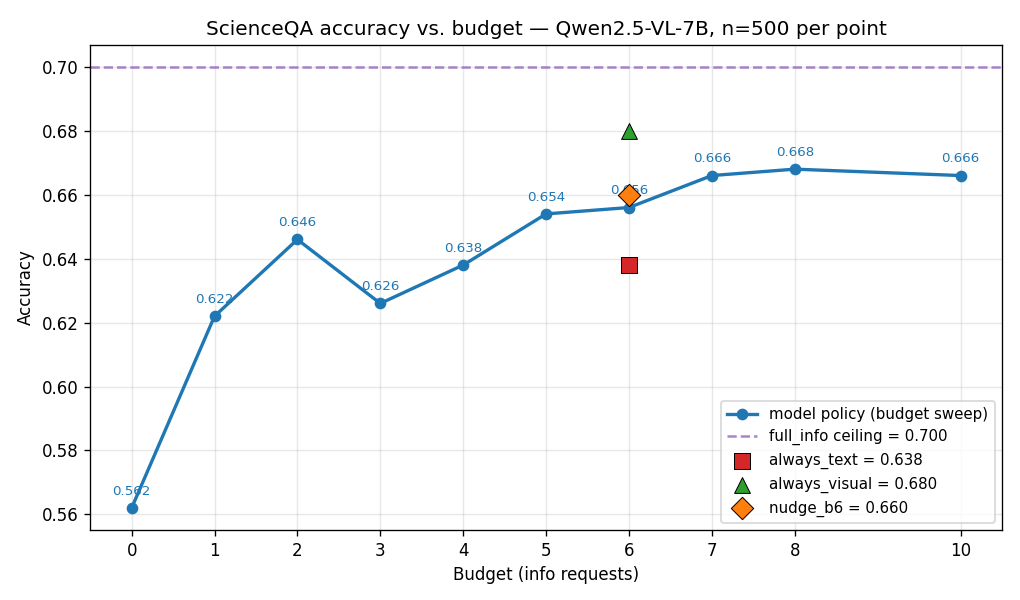

In [12]:
display(IPyImage(filename=str(PLOT_DIR / "accuracy_vs_budget.png")))


### 5-b. 정책별 모달리티 사용량


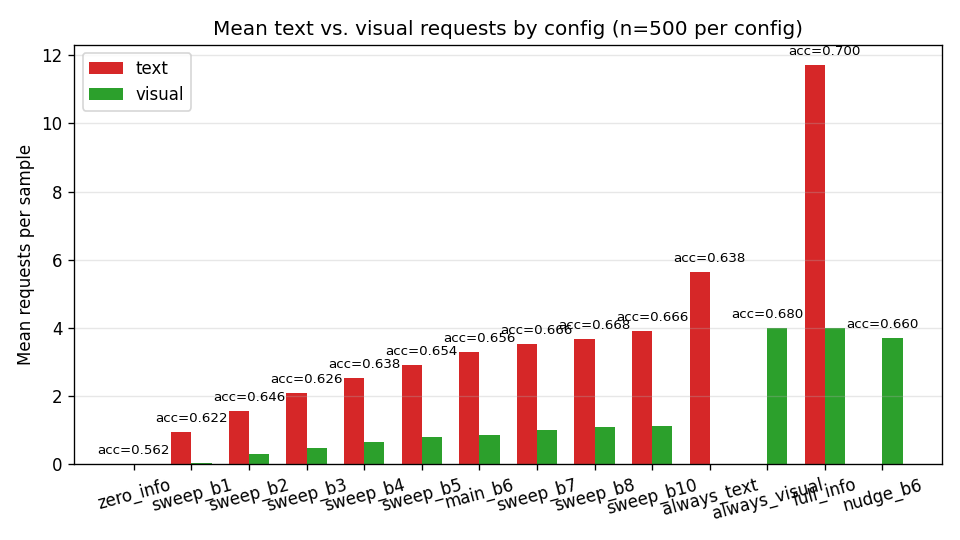

In [13]:
display(IPyImage(filename=str(PLOT_DIR / "modality_mix.png")))


### 5-c. Subject 별 정확도 (cross-tab)


In [14]:
crosstab = pd.read_csv(OUT_ROOT / "subject_crosstab.csv", index_col=0)
display(crosstab)


,language science,natural science,social science
run,,,
always_text,0.714,0.661,0.500
always_visual,0.929,0.695,0.553
full_info,0.714,0.729,0.539
main_b6,0.714,0.666,0.592
nudge_b6,0.929,0.673,0.539
sweep_b1,0.857,0.632,0.526
sweep_b10,0.714,0.685,0.553
sweep_b2,0.786,0.663,0.526
sweep_b3,0.714,0.639,0.539


### 5-d. Visual bias 분해 (main_b6 vs always_visual)

500개 샘플을 두 정책의 정답 여부 조합으로 4-bucket 분해:
- **both_right**: 둘 다 정답 / **both_wrong**: 둘 다 오답
- **visual_only**: always_visual만 정답 → "비전을 더 썼어야 했던" 케이스
- **main_only**: main_b6만 정답 → 모델이 텍스트로 풀어낸 케이스


In [15]:
bias = pd.read_csv(OUT_ROOT / "visual_bias_breakdown.csv")
display(bias["bucket"].value_counts().to_frame("count"))

vis_only = bias[bias["bucket"] == "visual_only"]
display(Markdown(
    f"**visual_only 코호트 ({len(vis_only)}개)에서 main_b6의 평균 사용량**:  "
    f"text **{vis_only['main_text'].mean():.2f}**회 / visual **{vis_only['main_visual'].mean():.2f}**회  "
    f"→ 비전이 답이었던 케이스에서조차 텍스트만 도배."
))

display(Markdown("**Subject별 bucket 비율:**"))
display(
    bias.groupby("subject")["bucket"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .round(3)
)


,count
bucket,
both_right,297
both_wrong,129
visual_only,43
main_only,31


**visual_only 코호트 (43개)에서 main_b6의 평균 사용량**:  text **3.91**회 / visual **0.81**회  → 비전이 답이었던 케이스에서조차 텍스트만 도배.

**Subject별 bucket 비율:**

bucket,both_right,both_wrong,main_only,visual_only
subject,,,,
language science,0.714,0.071,0.000,0.214
natural science,0.602,0.241,0.063,0.093
social science,0.526,0.382,0.066,0.026


## 6. Prompt nudge 실험

`run_nudge.py` — system prompt에 다음 가이드를 추가:

> "ScienceQA 이미지는 보통 4 타일로 쪼개지고 종종 결정적 시각 정보를 담는다. 텍스트 hint는 한 문장씩 끊겨서 자주 배경 설명이다. **REQUEST_TEXT를 default로 하지 마라**. 시각적 단서가 있는 질문이면 REQUEST_VISUAL을 우선해라."

가설: 텍스트 편향이 prompt만으로 옮겨가는가? `always_visual` 수준에 도달하는가?


In [16]:
nudge = load_run("nudge_b6")
av    = load_run("always_visual")

cmp = pd.concat([
    main["summary"].assign(run="main_b6 (no nudge)"),
    nudge["summary"].assign(run="nudge_b6 (with nudge)"),
    av["summary"].assign(run="always_visual (b=6)"),
], ignore_index=True)

cols = ["run", "accuracy", "mean_budget_used", "mean_text_requests",
        "mean_visual_requests", "mean_wasted", "forced_answer_rate"]
display(cmp[cols].style.format({c: "{:.3f}" for c in cols if c != "run"}))


,run,accuracy,mean_budget_used,mean_text_requests,mean_visual_requests,mean_wasted,forced_answer_rate
0,main_b6 (no nudge),0.656,4.178,3.282,0.872,0.024,0.316
1,nudge_b6 (with nudge),0.660,4.728,0.008,3.720,1.000,0.410
2,always_visual (b=6),0.680,4.000,0.000,4.000,0.000,1.000


**관찰**: nudge 한 줄로 모델 행동이 즉시 뒤집힘 — `text 3.28 → 0.01`, `visual 0.87 → 3.72`. 그러나 전체 정확도는 +0.4pp만 (0.656 → 0.660), `always_visual`(0.680)에는 못 미침. `wasted=1.0`이 평균적으로 발생 — 이미 소진된 visual을 또 요청.


In [17]:
display(Markdown("**Subject별 nudge 영향:**"))
sub_cmp = pd.concat([
    main["by_subject"].assign(run="main_b6"),
    nudge["by_subject"].assign(run="nudge_b6"),
    av["by_subject"].assign(run="always_visual"),
], ignore_index=True)
piv = sub_cmp.pivot(index="run", columns="subject", values="accuracy").round(3)
display(piv)


**Subject별 nudge 영향:**

subject,language science,natural science,social science
run,,,
always_visual,0.929,0.695,0.553
main_b6,0.714,0.666,0.592
nudge_b6,0.929,0.673,0.539


## 7. 인사이트 요약

자세한 해설은 별도 파일 [`INSIGHTS.md`](./INSIGHTS.md). 핵심 네 가지:

### ① 모델은 강한 텍스트 편향이고, 그게 손해다
- `main_b6`: text **3.28** / visual **0.87** (≈3.8배 텍스트 선호)
- `always_visual` (자동 비전만, b=6): **0.680** > main 0.656 > always_text 0.638

### ② visual_only 정답 케이스 43개(8.6%)를 main이 놓침
- 이 코호트에서 모델은 평균 text 3.91 / visual 0.81 사용 — 비전이 답이었던 곳에서조차 텍스트 도배

### ③ Prompt nudge는 modality preference를 즉시 뒤집지만 정확도는 거의 그대로
- `text 3.28 → 0.01`, `visual 0.87 → 3.72`로 완전 반전, 전체 +0.4pp
- 그러나 사회과학은 **−5.3pp** 악화 — 일률적 nudge는 너무 무딘 도구

### ④ Budget-accuracy 곡선은 비단조적이며 b≈7에서 포화
- **0 → 1: +6.0pp (가장 큰 단일 lift)**, 1 → 2: +2.4pp
- **b=2(0.646)에서 local max, b=3(0.626)에서 dip** — 모델 결정이 seed path 따라 불안정 (monotonic 아님)
- b≥7 이후 포화 (b=7/8/10 모두 0.666–0.668)
- `zero_info`만으로 0.562 → 사전지식으로 절반 이상 풀림. 정보 활용 lift 최대 +14pp (→ 0.700)


## 8. 재현 방법

```bash
cd /mnt/ddn/prod-runs/thyun.park/src/eval_sufficiency
uv sync

# 1. 전처리 (1회)
uv run python preprocessing.py --max-samples 500 --tile-grid 2

# 2. 메인 실험 (budget=6)
uv run python experiment_runner.py

# 3. 베이스라인 (zero_info, full_info, always_text, always_visual, b=4, b=8)
uv run python run_sweep.py

# 4. Dense budget sweep (b=1,2,3,5,7,10) — trace 저장 on
uv run python run_dense_sweep.py

# 5. Prompt nudge
uv run python run_nudge.py

# 6. 분석 + plot
uv run python summarize_runs.py
uv run python analyze_runs.py
```

각 run은 `output/<run>/predictions.{parquet,csv,jsonl}` + `summary_*.{csv,jsonl}`을 만든다. 500 샘플 × 정책 1개 ≈ **3–7분** (Qwen2.5-VL-7B-Instruct + H200, budget이 클수록 느림).


## (선택) 라이브 1샘플 데모

다음 셀은 **모델을 실제로 로드해서** 1개 샘플에 대해 episode를 돌립니다. 모델 로드 ~10초, 1 샘플 추론 ~10–20초. GPU 메모리 ~17GB.

기본은 `RUN_LIVE_DEMO = False` (스킵). True로 바꾸고 셀을 실행하면 라이브 trace가 print됩니다.


In [18]:
RUN_LIVE_DEMO = False  # True로 바꾸면 모델을 실제로 로드해 1샘플 실행

if RUN_LIVE_DEMO:
    import random
    import sys
    sys.path.insert(0, str(WORKSPACE))
    from budget_eval import EvalConfig, load_model_and_processor, run_episode

    sample = samples.iloc[0].to_dict()
    print(f"Demo sample: {sample['sample_id']}")
    print(f"Question: {sample['question']}\n")

    cfg = EvalConfig(
        preproc_dir=PREPROC,
        out_dir=OUT_ROOT / "live_demo",
        budget=6,
        random_seed=42,
        save_trace=True,
    )

    print("Loading model (this takes ~10s)...")
    model, processor = load_model_and_processor(cfg)

    rng = random.Random(cfg.random_seed)
    result = run_episode(model, processor, sample, cfg, rng)

    print(f"\n최종: action={result['final_action']}, choice={result['final_choice']}, "
          f"correct={result['is_correct']}")
    print(f"사용량: text={result['text_requests']}, visual={result['visual_requests']}, "
          f"budget_used={result['budget_used']}")
    print("\n스텝별 trace:")
    for s in result["trace"]:
        raw_short = s.get("raw", "")[:100].replace("\n", " ")
        print(f"  step {s['step']}: {s['action']:<14s} budget={s['budget_before']} "
              f"raw='{raw_short}'")
else:
    print("RUN_LIVE_DEMO=False — 라이브 실행을 보려면 위 변수를 True로 바꾸고 셀을 다시 실행하세요.")


RUN_LIVE_DEMO=False — 라이브 실행을 보려면 위 변수를 True로 바꾸고 셀을 다시 실행하세요.
